<a href="https://colab.research.google.com/github/Naseeha15/CNN-Assignment.ipynb/blob/main/CNN-Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print("Imports done!")
print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

Imports done!
TensorFlow: 2.19.0
GPU: []


In [ ]:
from google.colab import files
uploaded = files.upload()
# Upload both: sign_mnist_train.csv and sign_mnist_test.csv

Saving sign_mnist_train.csv to sign_mnist_train.csv
Saving sign_mnist_test.csv to sign_mnist_test.csv


In [ ]:
train_df = pd.read_csv('sign_mnist_train.csv')
test_df  = pd.read_csv('sign_mnist_test.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape : {test_df.shape}")

def preprocess(df):
    labels = df['label'].values
    pixels = df.drop('label', axis=1).values
    images = pixels.reshape(-1, 28, 28, 1).astype('float32') / 255.0

    # Map labels to a 0-23 range, skipping 'J' (9) and 'Z' (25)
    # This handles the non-contiguous nature of the Sign MNIST dataset
    # where J and Z are often excluded.
    new_labels = []
    for label in labels:
        if label > 9:
            new_labels.append(label - 1)
        else:
            new_labels.append(label)
    labels = np.array(new_labels)

    return images, labels

X_train_full, y_train_full = preprocess(train_df)
X_test, y_test             = preprocess(test_df)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

print(f"X_train: {X_train.shape}")
print(f"X_val  : {X_val.shape}")
print(f"X_test : {X_test.shape}")

Train shape: (27455, 785)
Test shape : (7172, 785)
X_train: (21964, 28, 28, 1)
X_val  : (5491, 28, 28, 1)
X_test : (7172, 28, 28, 1)


In [ ]:
def label_to_letter(lbl):
    alphabet = [chr(65 + i) for i in range(26) if i not in [9, 25]]
    label_map = {}
    used = 0
    for i in range(26):
        if i not in [9, 25]:
            label_map[i] = alphabet[used]
            used += 1
    return label_map.get(lbl, '?')

def plot_history(history, title='Training History'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    axes[0].plot(history.history['accuracy'],     label='Train Acc',  linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Acc',    linewidth=2, linestyle='--')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def evaluate_model(model, X_test, y_test, model_name='Model'):
    y_pred    = np.argmax(model.predict(X_test, verbose=0), axis=1)
    test_acc  = np.mean(y_pred == y_test)
    print(f'\n===== {model_name} — Test Accuracy: {test_acc:.4f} =====')

    unique_labels = np.unique(np.concatenate([y_test, y_pred]))
    target_names  = [label_to_letter(l) for l in unique_labels]
    print(classification_report(y_test, y_pred, labels=unique_labels, target_names=target_names))

    cm = confusion_matrix(y_test, y_pred, labels=unique_labels)
    plt.figure(figsize=(14, 11))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Confusion Matrix — {model_name}', fontsize=14, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    return y_pred, test_acc

print("Helper functions ready!")

Helper functions ready!


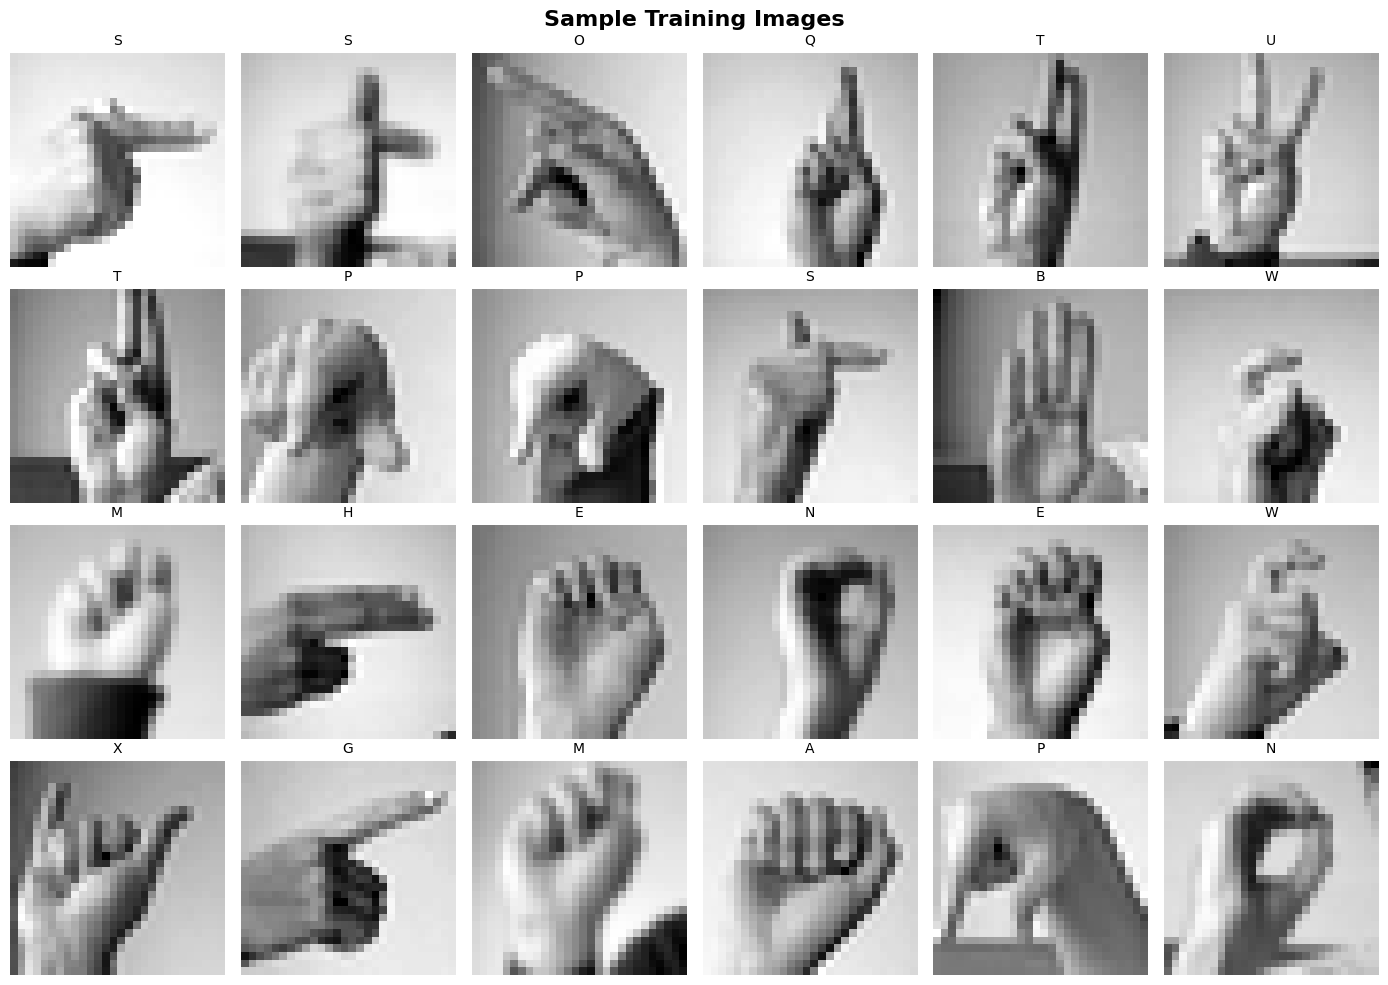

In [ ]:
fig, axes = plt.subplots(4, 6, figsize=(14, 10))
fig.suptitle('Sample Training Images', fontsize=16, fontweight='bold')
for ax in axes.flatten():
    idx = np.random.randint(len(X_train))
    ax.imshow(X_train[idx].squeeze(), cmap='gray')
    ax.set_title(label_to_letter(y_train[idx]), fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,577 (1.62 MB)

 Trainable params: 423,577 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 32s 88ms/step - accuracy: 0.5394 - loss: 1.5128 - val_accuracy: 0.9035 - val_loss: 0.3644 - learning_rate: 0.0010
Epoch 2/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 31s 89ms/step - accuracy: 0.8883 - loss: 0.3456 - val_accuracy: 0.9907 - val_loss: 0.0875 - learning_rate: 0.0010
Epoch 3/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 40s 86ms/step - accuracy: 0.9577 - loss: 0.1409 - val_accuracy: 0.9978 - val_loss: 0.0245 - learning_rate: 0.0010
Epoch 4/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 30s 88ms/step - accuracy: 0.9756 - loss: 0.0792 - val_accuracy: 1.0000 - val_loss: 0.0080 - learning_rate: 0.0010
Epoch 5/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 31s 91ms/step - accuracy: 0.9850 - loss: 0.0511 - val_accuracy: 1.0000 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 6/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 31s 89ms/step - accuracy: 0.9889 - loss: 0.0385 - val_accuracy: 1.0000 - val_loss: 0.0031 - learning_rate: 0.0010
Epoch 7/30
344/344 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - accuracy: 0.9912 - l

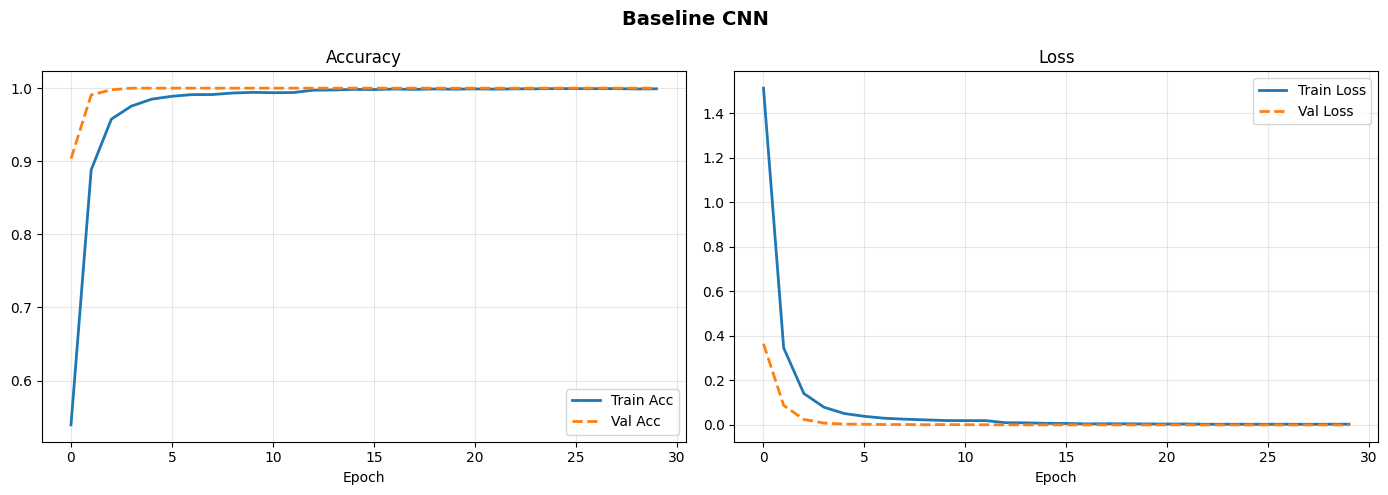

In [ ]:
# CELL 6 — Build and Train Baseline CNN

def build_baseline_cnn(num_classes=25, input_shape=(28, 28, 1)):  # changed 24 → 25
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ], name='Baseline_CNN')
    return model

baseline_model = build_baseline_cnn()
baseline_model.summary()

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_baseline = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

t0 = time.time()
history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=callbacks_baseline,
    verbose=1
)
print(f"Training time: {time.time()-t0:.1f}s")
plot_history(history_baseline, 'Baseline CNN')

Model: "Deep_CNN_BN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 572,953 (2.19 MB)

 Trainable params: 572,249 (2.18 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 101s 279ms/step - accuracy: 0.4500 - loss: 1.7994 - val_accuracy: 0.3484 - val_loss: 2.3975 - learning_rate: 0.0010
Epoch 2/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7500 - loss: 0.7735 - val_accuracy: 0.3566 - val_loss: 2.3848 - learning_rate: 0.0010
Epoch 3/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 94s 274ms/step - accuracy: 0.8465 - loss: 0.4999 - val_accuracy: 0.9435 - val_loss: 0.2202 - learning_rate: 0.0010
Epoch 4/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.8750 - loss: 0.3791 - val_accuracy: 0.9499 - val_loss: 0.1981 - learning_rate: 0.0010
Epoch 5/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 133s 278ms/step - accuracy: 0.9325 - loss: 0.2502 - val_accuracy: 0.9716 - val_loss: 0.1222 - learning_rate: 0.0010
Epoch 6/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9531 - loss: 0.1630 - val_accuracy: 0.9705 - val_loss: 0.1271 - learning_rate: 0.0010
Epoch 7/40
343/343 ━━━━━━━━━━━━━━━━━━━━ 100s 292ms/step - accuracy: 0.954

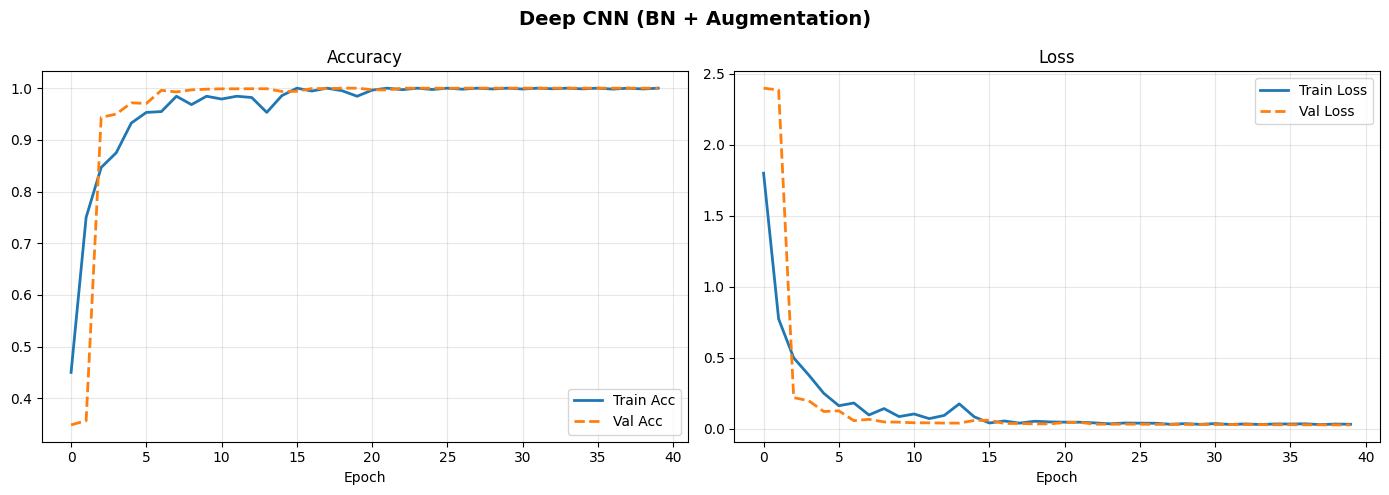

In [ ]:
def build_deep_cnn(num_classes=25, input_shape=(28, 28, 1)):
    inp = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3,3), padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(64, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs=inp, outputs=out, name='Deep_CNN_BN')

deep_model = build_deep_cnn()
deep_model.summary()

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=False
)
datagen.fit(X_train)

deep_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_deep = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

t0 = time.time()
history_deep = deep_model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    validation_data=(X_val, y_val),
    epochs=40,
    steps_per_epoch=len(X_train) // 64,
    callbacks=callbacks_deep,
    verbose=1
)
print(f"Training time: {time.time()-t0:.1f}s")
plot_history(history_deep, 'Deep CNN (BN + Augmentation)')

Model: "VGG_Style"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)              │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 25)             │        12,825 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 1,292,249 (4.93 MB)

 Trainable params: 1,290,457 (4.92 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 529s 2s/step - accuracy: 0.7142 - loss: 0.9561 - val_accuracy: 0.0938 - val_loss: 4.7526 - learning_rate: 5.0000e-04
Epoch 2/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 29s 80ms/step - accuracy: 0.9219 - loss: 0.2430 - val_accuracy: 0.0830 - val_loss: 4.7198 - learning_rate: 5.0000e-04
Epoch 3/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 490s 1s/step - accuracy: 0.9778 - loss: 0.1141 - val_accuracy: 0.9989 - val_loss: 0.0500 - learning_rate: 5.0000e-04
Epoch 4/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 43s 120ms/step - accuracy: 1.0000 - loss: 0.0928 - val_accuracy: 0.9984 - val_loss: 0.0510 - learning_rate: 5.0000e-04
Epoch 5/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 511s 1s/step - accuracy: 0.9887 - loss: 0.0783 - val_accuracy: 0.9993 - val_loss: 0.0397 - learning_rate: 5.0000e-04
Epoch 6/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 30s 83ms/step - accuracy: 0.9844 - loss: 0.1072 - val_accuracy: 1.0000 - val_loss: 0.0382 - learning_rate: 5.0000e-04
Epoch 7/50
343/343 ━━━━━━━━━━━━━━━━━━━━ 501s 1s/step -

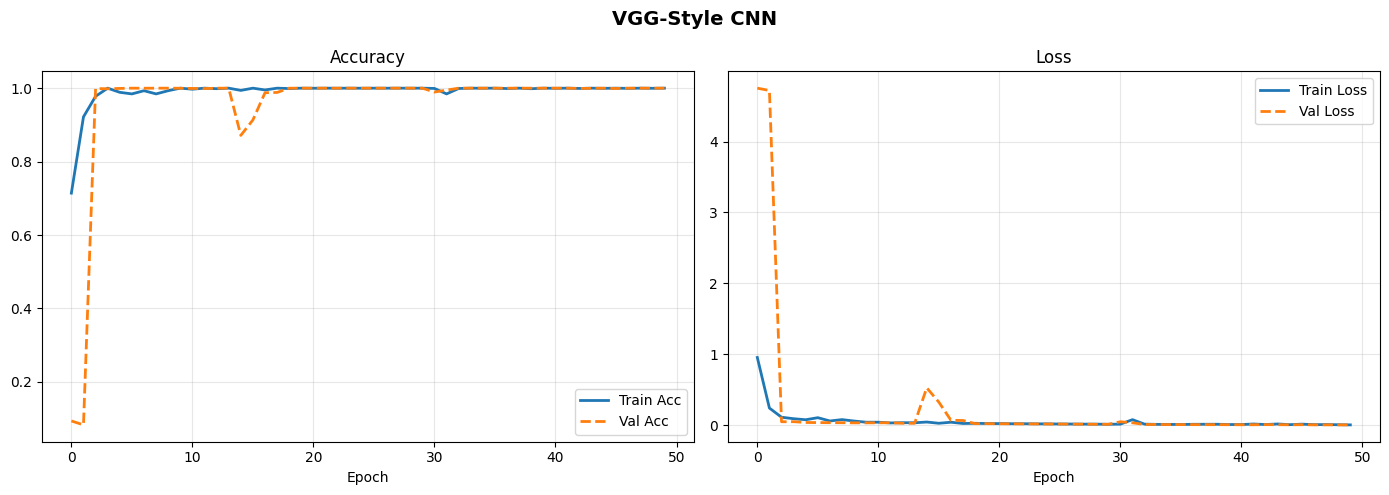

In [ ]:
def build_vgg_style(num_classes=25, input_shape=(28, 28, 1)):
    model = models.Sequential(name='VGG_Style')
    model.add(layers.InputLayer(input_shape=input_shape))

    # Block 1 — 64 filters
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # Block 2 — 128 filters
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # Block 3 — 256 filters
    model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.25))

    # Classifier
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

vgg_model = build_vgg_style()
vgg_model.summary()

vgg_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_vgg = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]

t0 = time.time()
history_vgg = vgg_model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    validation_data=(X_val, y_val),
    epochs=50,
    steps_per_epoch=len(X_train) // 64,
    callbacks=callbacks_vgg,
    verbose=1
)
print(f"Training time: {time.time()-t0:.1f}s")
plot_history(history_vgg, 'VGG-Style CNN')


===== Baseline CNN — Test Accuracy: 0.9317 =====
              precision    recall  f1-score   support

           A       0.94      1.00      0.97       331
           B       1.00      1.00      1.00       432
           C       1.00      1.00      1.00       310
           D       0.87      1.00      0.93       245
           E       0.96      0.99      0.98       498
           F       1.00      1.00      1.00       247
           G       0.94      0.94      0.94       348
           H       0.91      0.95      0.93       436
           I       0.85      0.79      0.82       288
           ?       0.98      0.94      0.96       331
           K       0.91      1.00      0.95       209
           L       0.91      0.95      0.93       394
           M       1.00      0.78      0.88       291
           N       1.00      1.00      1.00       246
           O       1.00      1.00      1.00       347
           P       0.89      1.00      0.94       164
           Q       0.98      0.

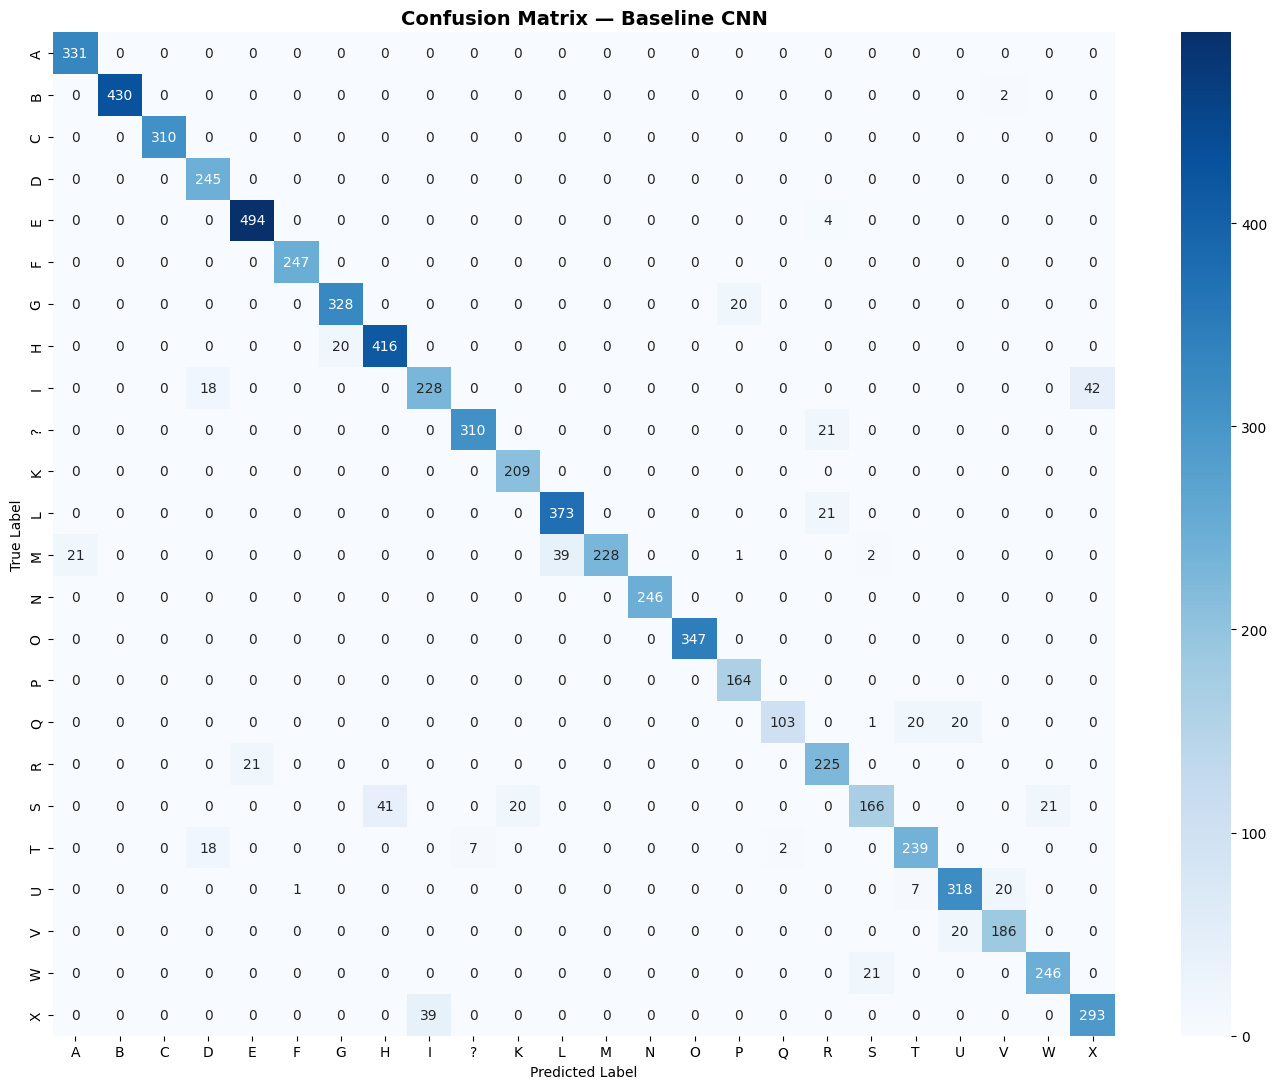


===== Deep CNN (BN) — Test Accuracy: 1.0000 =====
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       331
           B       1.00      1.00      1.00       432
           C       1.00      1.00      1.00       310
           D       1.00      1.00      1.00       245
           E       1.00      1.00      1.00       498
           F       1.00      1.00      1.00       247
           G       1.00      1.00      1.00       348
           H       1.00      1.00      1.00       436
           I       1.00      1.00      1.00       288
           ?       1.00      1.00      1.00       331
           K       1.00      1.00      1.00       209
           L       1.00      1.00      1.00       394
           M       1.00      1.00      1.00       291
           N       1.00      1.00      1.00       246
           O       1.00      1.00      1.00       347
           P       1.00      1.00      1.00       164
           Q       1.00      1

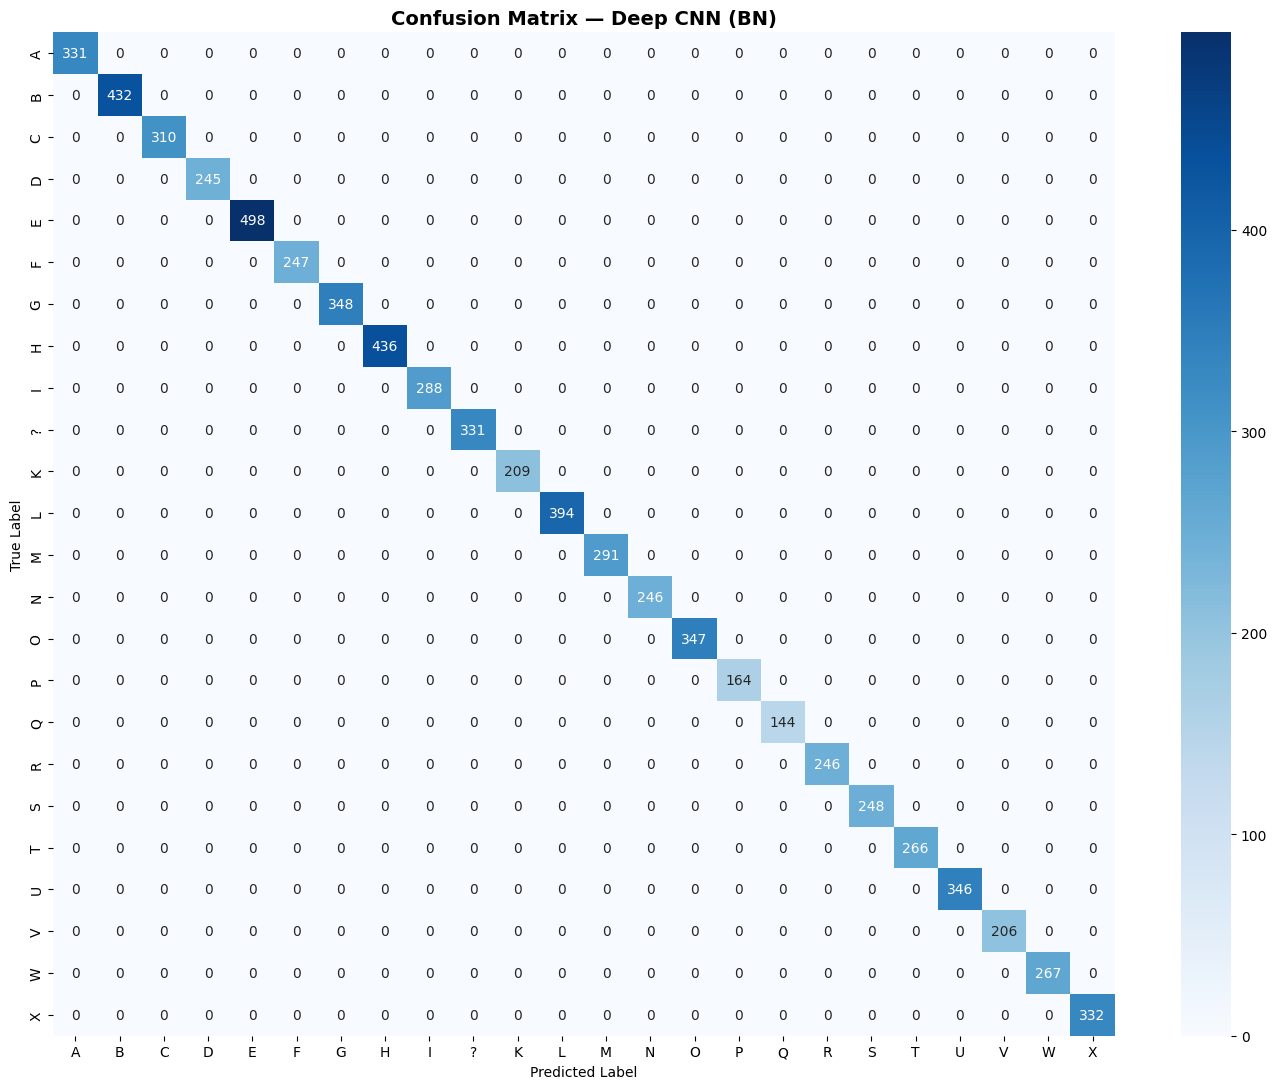


===== VGG-Style CNN — Test Accuracy: 1.0000 =====
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       331
           B       1.00      1.00      1.00       432
           C       1.00      1.00      1.00       310
           D       1.00      1.00      1.00       245
           E       1.00      1.00      1.00       498
           F       1.00      1.00      1.00       247
           G       1.00      1.00      1.00       348
           H       1.00      1.00      1.00       436
           I       1.00      1.00      1.00       288
           ?       1.00      1.00      1.00       331
           K       1.00      1.00      1.00       209
           L       1.00      1.00      1.00       394
           M       1.00      1.00      1.00       291
           N       1.00      1.00      1.00       246
           O       1.00      1.00      1.00       347
           P       1.00      1.00      1.00       164
           Q       1.00      1

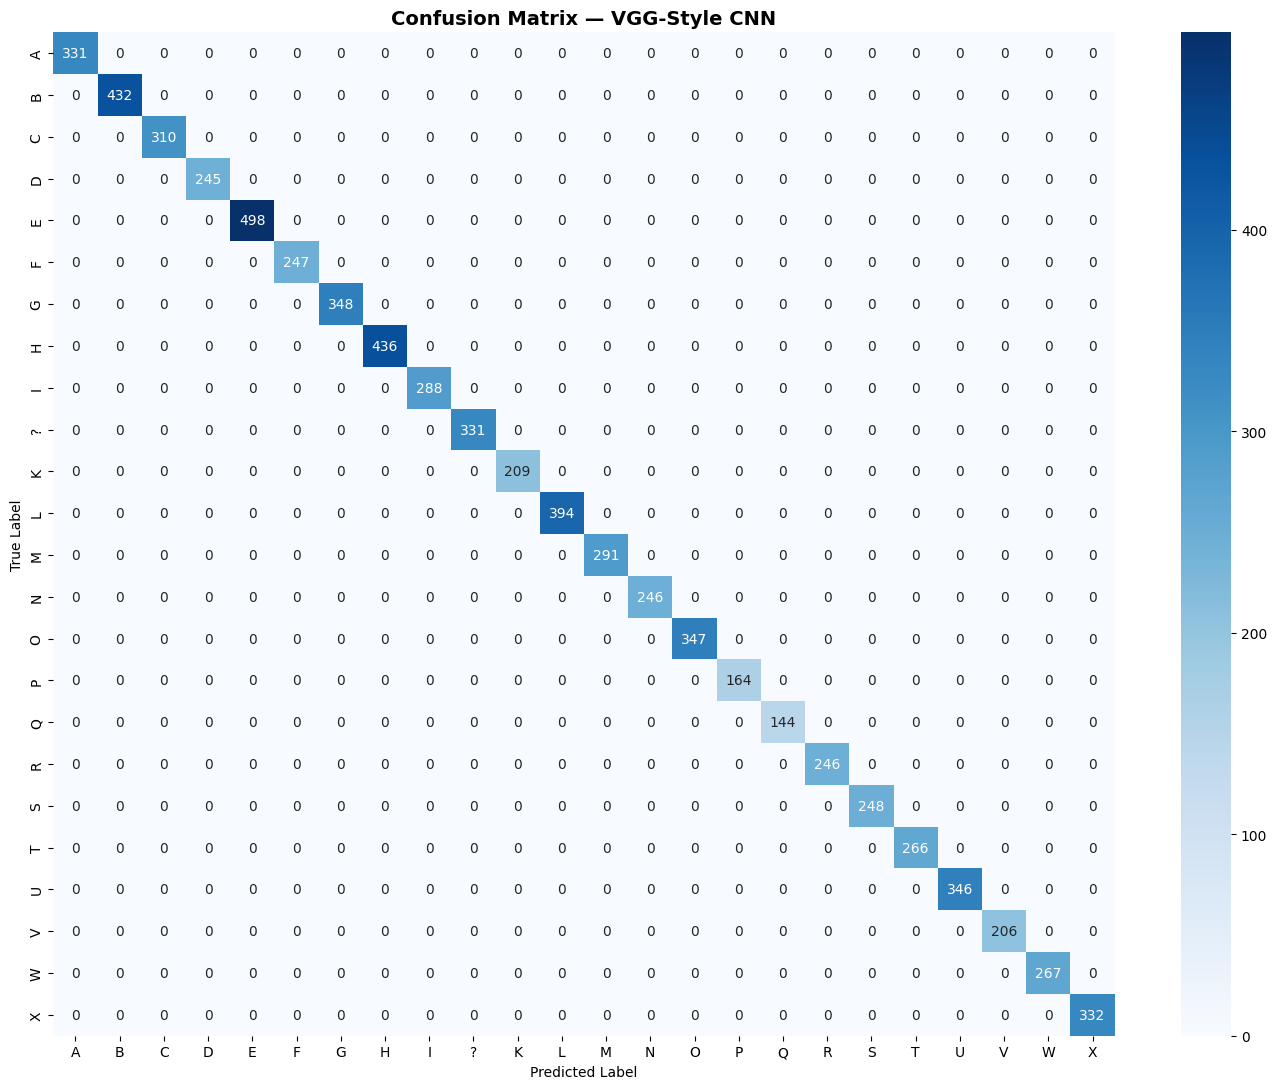

In [ ]:
_, baseline_acc = evaluate_model(baseline_model, X_test, y_test, 'Baseline CNN')
_, deep_acc     = evaluate_model(deep_model,     X_test, y_test, 'Deep CNN (BN)')
_, vgg_acc      = evaluate_model(vgg_model,      X_test, y_test, 'VGG-Style CNN')

In [ ]:
comparison = pd.DataFrame({
    'Model'        : ['Baseline CNN', 'Deep CNN (BN)', 'VGG-Style'],
    'Parameters'   : [baseline_model.count_params(),
                      deep_model.count_params(),
                      vgg_model.count_params()],
    'Test Accuracy': [f"{baseline_acc:.4f}",
                      f"{deep_acc:.4f}",
                      f"{vgg_acc:.4f}"]
})
print(comparison.to_string(index=False))

        Model  Parameters Test Accuracy
 Baseline CNN      423577        0.9317
Deep CNN (BN)      572953        1.0000
    VGG-Style     1292249        1.0000


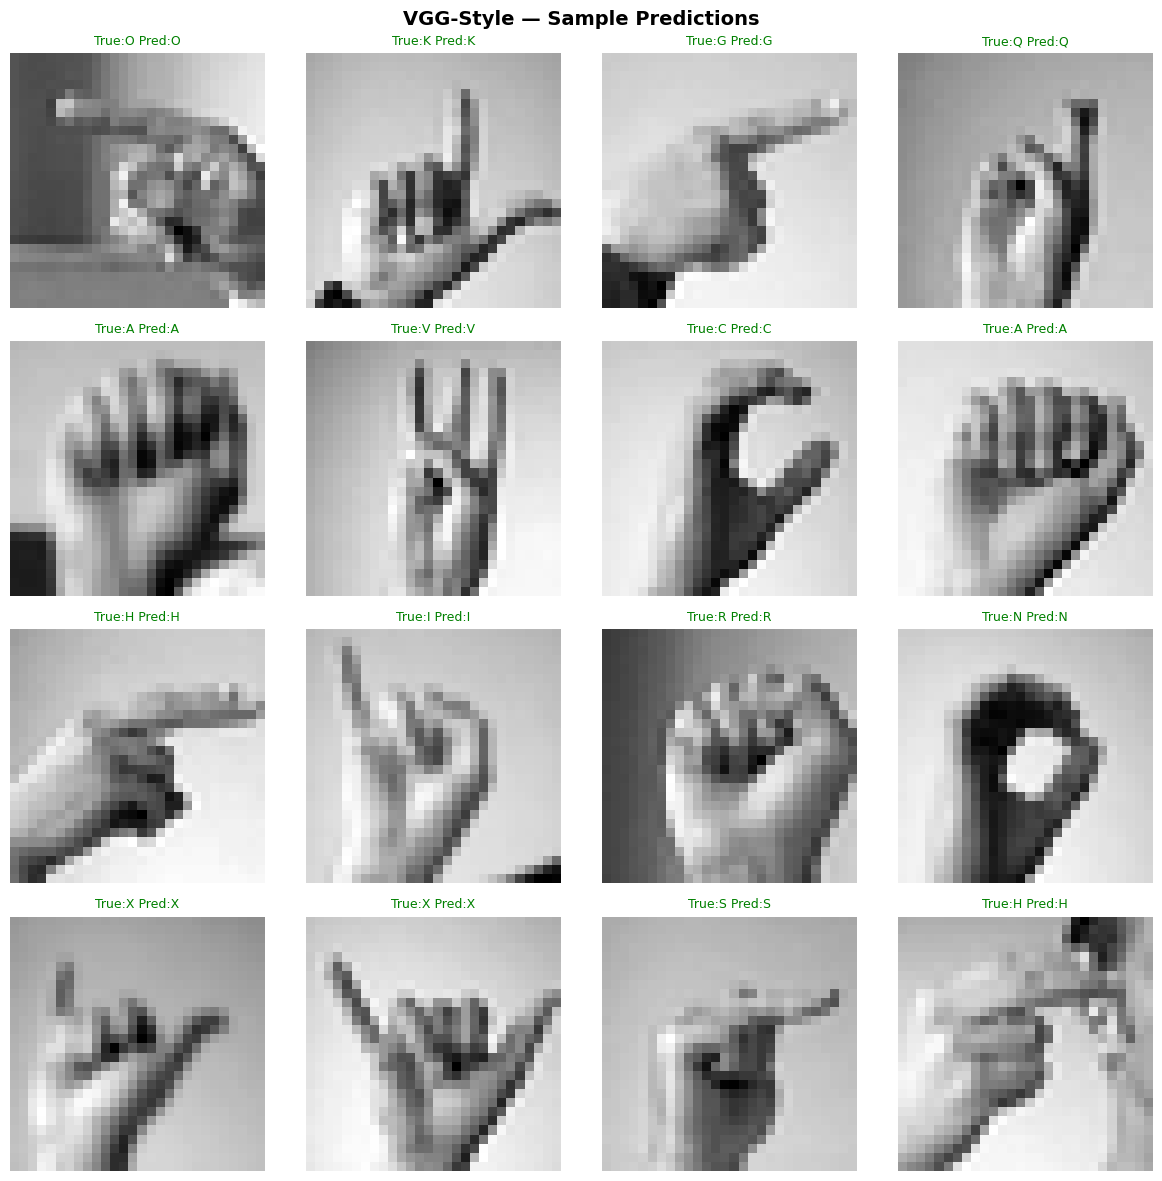

In [ ]:
y_pred_vgg = np.argmax(vgg_model.predict(X_test, verbose=0), axis=1)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('VGG-Style — Sample Predictions', fontsize=14, fontweight='bold')
indices = np.random.choice(len(X_test), 16, replace=False)

for ax, idx in zip(axes.flatten(), indices):
    ax.imshow(X_test[idx].squeeze(), cmap='gray')
    true_lbl = label_to_letter(y_test[idx])
    pred_lbl = label_to_letter(y_pred_vgg[idx])
    colour   = 'green' if true_lbl == pred_lbl else 'red'
    ax.set_title(f'True:{true_lbl} Pred:{pred_lbl}', color=colour, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

Total misclassified: 0 / 7172


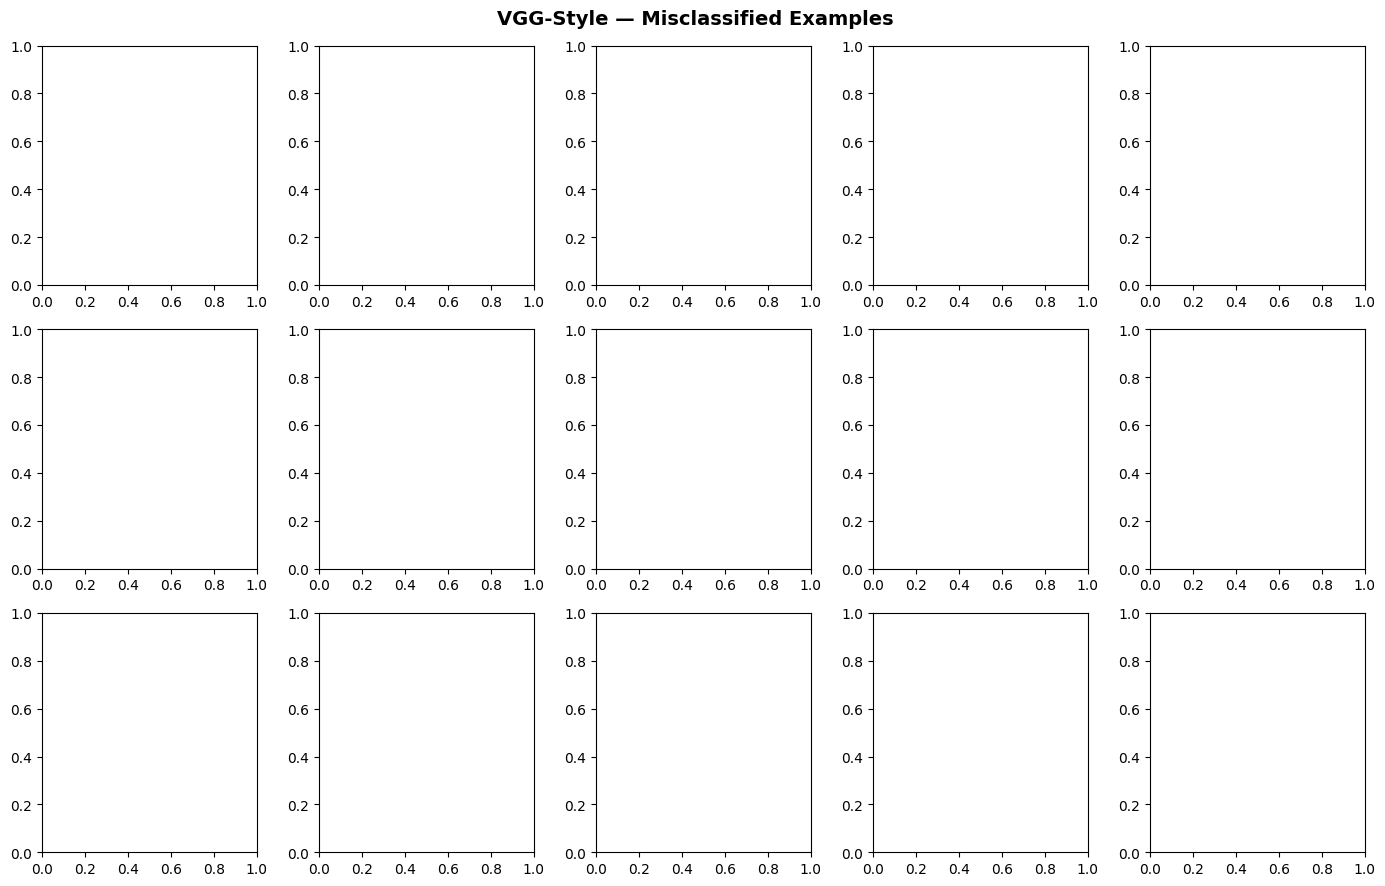

In [ ]:
misclassified = np.where(y_pred_vgg != y_test)[0]
print(f'Total misclassified: {len(misclassified)} / {len(y_test)}')

fig, axes = plt.subplots(3, 5, figsize=(14, 9))
fig.suptitle('VGG-Style — Misclassified Examples', fontsize=14, fontweight='bold')
sample_misc = np.random.choice(misclassified, min(15, len(misclassified)), replace=False)

for ax, idx in zip(axes.flatten(), sample_misc):
    ax.imshow(X_test[idx].squeeze(), cmap='gray')
    true_lbl = label_to_letter(y_test[idx])
    pred_lbl = label_to_letter(y_pred_vgg[idx])
    ax.set_title(f'True:{true_lbl}\nPred:{pred_lbl}', color='red', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
unique_labels = np.unique(y_test)
cm = confusion_matrix(y_test, y_pred_vgg, labels=unique_labels)
np.fill_diagonal(cm, 0)

errors = []
for i, true in enumerate(unique_labels):
    for j, pred in enumerate(unique_labels):
        if cm[i, j] > 0:
            errors.append((label_to_letter(true), label_to_letter(pred), cm[i, j]))
errors.sort(key=lambda x: -x[2])

print("Top 10 Most Confused Pairs (True → Predicted):")
for true, pred, count in errors[:10]:
    print(f"  {true} → {pred} : {count} errors")

Top 10 Most Confused Pairs (True → Predicted):


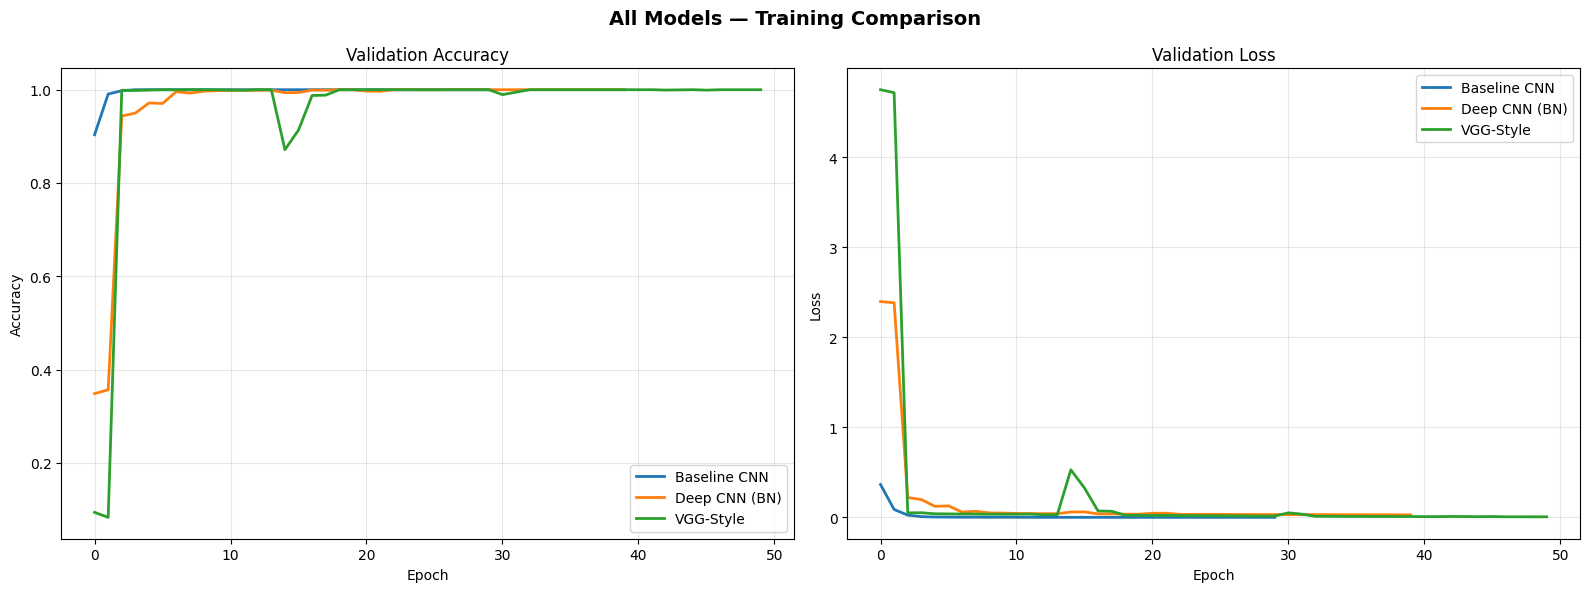

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('All Models — Training Comparison', fontsize=14, fontweight='bold')

# Accuracy
axes[0].plot(history_baseline.history['val_accuracy'], label='Baseline CNN',    linewidth=2)
axes[0].plot(history_deep.history['val_accuracy'],     label='Deep CNN (BN)',   linewidth=2)
axes[0].plot(history_vgg.history['val_accuracy'],      label='VGG-Style',       linewidth=2)
axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history_baseline.history['val_loss'], label='Baseline CNN',  linewidth=2)
axes[1].plot(history_deep.history['val_loss'],     label='Deep CNN (BN)', linewidth=2)
axes[1].plot(history_vgg.history['val_loss'],      label='VGG-Style',     linewidth=2)
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

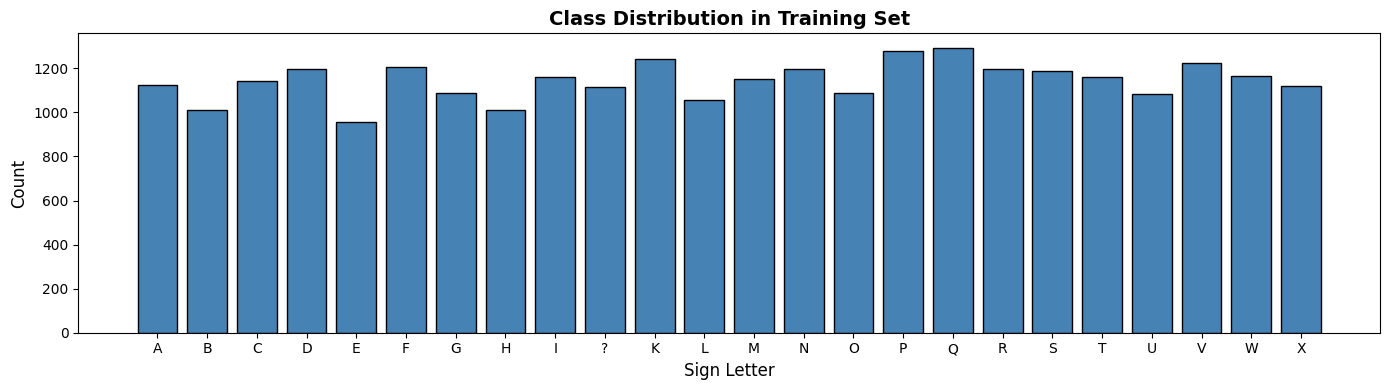

In [ ]:
unique, counts = np.unique(y_train_full, return_counts=True)
letters = [label_to_letter(u) for u in unique]

plt.figure(figsize=(14, 4))
plt.bar(letters, counts, color='steelblue', edgecolor='black')
plt.xlabel('Sign Letter', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Class Distribution in Training Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 50)
print("         FINAL MODEL SUMMARY")
print("=" * 50)
print(f"Baseline CNN  — Parameters: {baseline_model.count_params():,}  |  Test Accuracy: {baseline_acc:.4f}")
print(f"Deep CNN (BN) — Parameters: {deep_model.count_params():,}  |  Test Accuracy: {deep_acc:.4f}")
print(f"VGG-Style     — Parameters: {vgg_model.count_params():,}  |  Test Accuracy: {vgg_acc:.4f}")
print("=" * 50)
best = max([('Baseline CNN', baseline_acc), ('Deep CNN (BN)', deep_acc), ('VGG-Style', vgg_acc)], key=lambda x: x[1])
print(f"Best Model: {best[0]} with accuracy {best[1]:.4f}")
print("=" * 50)

         FINAL MODEL SUMMARY
Baseline CNN  — Parameters: 423,577  |  Test Accuracy: 0.9317
Deep CNN (BN) — Parameters: 572,953  |  Test Accuracy: 1.0000
VGG-Style     — Parameters: 1,292,249  |  Test Accuracy: 1.0000
Best Model: Deep CNN (BN) with accuracy 1.0000
